In [ ]:
import pandas as pd
file_path = ('/content/goibibo_flights_data.csv')
data = pd.read_csv(file_path)
print(data.head())

  flight date   airline flight_num    class   from dep_time      to arr_time  \
0  26-06-2023  SpiceJet    SG-8709  economy  Delhi    18:55  Mumbai    21:05   
1  26-06-2023  SpiceJet    SG-8157  economy  Delhi    06:20  Mumbai    08:40   
2  26-06-2023   AirAsia     I5-764  economy  Delhi    04:25  Mumbai    06:35   
3  26-06-2023   Vistara     UK-995  economy  Delhi    10:20  Mumbai    12:35   
4  26-06-2023   Vistara     UK-963  economy  Delhi    08:50  Mumbai    11:10   

  duration  price     stops  Unnamed: 11  Unnamed: 12  
0  02h 10m  6,013  non-stop          NaN          NaN  
1  02h 20m  6,013  non-stop          NaN          NaN  
2  02h 10m  6,016  non-stop          NaN          NaN  
3  02h 15m  6,015  non-stop          NaN          NaN  
4  02h 20m  6,015  non-stop          NaN          NaN  


##Phase 1: Data Cleaning

In [ ]:
data.head()

,flight date,airline,flight_num,class,from,dep_time,to,arr_time,duration,price,stops,Unnamed: 11,Unnamed: 12
0,26-06-2023,SpiceJet,SG-8709,economy,Delhi,18:55,Mumbai,21:05,02h 10m,"6,013",non-stop,NaN,NaN
1,26-06-2023,SpiceJet,SG-8157,economy,Delhi,06:20,Mumbai,08:40,02h 20m,"6,013",non-stop,NaN,NaN
2,26-06-2023,AirAsia,I5-764,economy,Delhi,04:25,Mumbai,06:35,02h 10m,"6,016",non-stop,NaN,NaN
3,26-06-2023,Vistara,UK-995,economy,Delhi,10:20,Mumbai,12:35,02h 15m,"6,015",non-stop,NaN,NaN
4,26-06-2023,Vistara,UK-963,economy,Delhi,08:50,Mumbai,11:10,02h 20m,"6,015",non-stop,NaN,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300261 entries, 0 to 300260
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   flight date  300261 non-null  object 
 1   airline      300261 non-null  object 
 2   flight_num   300261 non-null  object 
 3   class        300261 non-null  object 
 4   from         300261 non-null  object 
 5   dep_time     300261 non-null  object 
 6   to           300261 non-null  object 
 7   arr_time     300261 non-null  object 
 8   duration     300261 non-null  object 
 9   price        300261 non-null  object 
 10  stops        300261 non-null  object 
 11  Unnamed: 11  0 non-null       float64
 12  Unnamed: 12  0 non-null       float64
dtypes: float64(2), object(11)
memory usage: 29.8+ MB


In [ ]:
data.head()

,flight date,airline,flight_num,class,from,dep_time,to,arr_time,duration,price,stops
0,26-06-2023,SpiceJet,SG-8709,economy,Delhi,18:55,Mumbai,21:05,02h 10m,"6,013",non-stop
1,26-06-2023,SpiceJet,SG-8157,economy,Delhi,06:20,Mumbai,08:40,02h 20m,"6,013",non-stop
2,26-06-2023,AirAsia,I5-764,economy,Delhi,04:25,Mumbai,06:35,02h 10m,"6,016",non-stop
3,26-06-2023,Vistara,UK-995,economy,Delhi,10:20,Mumbai,12:35,02h 15m,"6,015",non-stop
4,26-06-2023,Vistara,UK-963,economy,Delhi,08:50,Mumbai,11:10,02h 20m,"6,015",non-stop


In [ ]:
data.isnull().sum()

,0
flight date,0
airline,0
flight_num,0
class,0
from,0
dep_time,0
to,0
arr_time,0
duration,0
price,0


In [ ]:
data.duplicated().sum()

np.int64(2)

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
print("Number of duplicates after removal:", data.duplicated().sum())

Number of duplicates after removal: 0


In [ ]:
data.head()

,flight date,airline,flight_num,class,from,dep_time,to,arr_time,duration,price,stops
0,26-06-2023,SpiceJet,SG-8709,economy,Delhi,18:55,Mumbai,21:05,02h 10m,"6,013",non-stop
1,26-06-2023,SpiceJet,SG-8157,economy,Delhi,06:20,Mumbai,08:40,02h 20m,"6,013",non-stop
2,26-06-2023,AirAsia,I5-764,economy,Delhi,04:25,Mumbai,06:35,02h 10m,"6,016",non-stop
3,26-06-2023,Vistara,UK-995,economy,Delhi,10:20,Mumbai,12:35,02h 15m,"6,015",non-stop
4,26-06-2023,Vistara,UK-963,economy,Delhi,08:50,Mumbai,11:10,02h 20m,"6,015",non-stop


In [ ]:
data['duration'].head(10)

,duration
0,0 days 02:10:00
1,0 days 02:20:00
2,0 days 02:10:00
3,0 days 02:15:00
4,0 days 02:20:00
5,0 days 02:20:00
6,0 days 02:05:00
7,0 days 02:10:00
8,0 days 02:10:00
9,0 days 02:15:00


In [ ]:
# The 'duration' column is already in timedelta format.
# To get the duration in minutes, we can directly extract it from the timedelta objects.
data['duration_minutes'] = data['duration'].dt.total_seconds() / 60

print("Duration converted to minutes successfully.")
print(data[['duration', 'duration_minutes']].head())

Duration converted to minutes successfully.
         duration  duration_minutes
0 0 days 02:10:00             130.0
1 0 days 02:20:00             140.0
2 0 days 02:10:00             130.0
3 0 days 02:15:00             135.0
4 0 days 02:20:00             140.0


In [ ]:
data[['duration', 'duration_minutes']].head(10)

,duration,duration_minutes
0,0 days 02:10:00,130.0
1,0 days 02:20:00,140.0
2,0 days 02:10:00,130.0
3,0 days 02:15:00,135.0
4,0 days 02:20:00,140.0
5,0 days 02:20:00,140.0
6,0 days 02:05:00,125.0
7,0 days 02:10:00,130.0
8,0 days 02:10:00,130.0
9,0 days 02:15:00,135.0


In [ ]:
print(data.columns)

Index(['flight date', 'airline', 'flight_num', 'class', 'from', 'dep_time',
       'to', 'arr_time', 'duration', 'price', 'stops', 'duration_minutes'],
      dtype='object')


In [ ]:
data.head()

,flight date,airline,flight_num,class,from,dep_time,to,arr_time,duration,price,stops,duration_minutes
0,2023-06-26,SpiceJet,SG-8709,economy,Delhi,18:55:00,Mumbai,21:05:00,0 days 02:10:00,6013,non-stop,130.0
1,2023-06-26,SpiceJet,SG-8157,economy,Delhi,06:20:00,Mumbai,08:40:00,0 days 02:20:00,6013,non-stop,140.0
2,2023-06-26,AirAsia,I5-764,economy,Delhi,04:25:00,Mumbai,06:35:00,0 days 02:10:00,6016,non-stop,130.0
3,2023-06-26,Vistara,UK-995,economy,Delhi,10:20:00,Mumbai,12:35:00,0 days 02:15:00,6015,non-stop,135.0
4,2023-06-26,Vistara,UK-963,economy,Delhi,08:50:00,Mumbai,11:10:00,0 days 02:20:00,6015,non-stop,140.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300259 entries, 0 to 300260
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype          
---  ------            --------------   -----          
 0   flight date       300259 non-null  datetime64[ns] 
 1   airline           300259 non-null  object         
 2   flight_num        300259 non-null  object         
 3   class             300259 non-null  object         
 4   from              300259 non-null  object         
 5   dep_time          300259 non-null  object         
 6   to                300259 non-null  object         
 7   arr_time          300259 non-null  object         
 8   duration          300259 non-null  timedelta64[ns]
 9   price             300259 non-null  int64          
 10  stops             300259 non-null  object         
 11  duration_minutes  300259 non-null  float64        
dtypes: datetime64[ns](1), float64(1), int64(1), object(8), timedelta64[ns](1)
memory usage: 29.8+ MB


In [ ]:
data.isnull().sum()

,0
flight date,0
airline,0
flight_num,0
class,0
from,0
dep_time,0
to,0
arr_time,0
duration,0
price,0


## Phase 2 Feature Engineering


1 Route Column

In [ ]:
data['route'] = data['from'] + ' → ' + data['to']
data[['from','to','route']].head()

,from,to,route
0,Delhi,Mumbai,Delhi → Mumbai
1,Delhi,Mumbai,Delhi → Mumbai
2,Delhi,Mumbai,Delhi → Mumbai
3,Delhi,Mumbai,Delhi → Mumbai
4,Delhi,Mumbai,Delhi → Mumbai


2 Flight Date Features

In [ ]:
data['flight date'] = pd.to_datetime(data['flight date'])

Month

In [ ]:
data['month'] = data['flight date'].dt.month

Day

In [ ]:
data['day'] = data['flight date'].dt.day

Day Name

In [ ]:
data['day_name'] = data['flight date'].dt.day_name()

Weekday Number

In [ ]:
data['weekday'] = data['flight date'].dt.dayofweek

3 Weekend Flag

In [ ]:
data['is_weekend'] = (data['flight date'].dt.dayofweek >= 5).astype(int)

4 Departure Hour Extract

In [ ]:
data['dep_hour'] = pd.to_datetime(
    data['dep_time'],
    format='%H:%M:%S'
).dt.hour

In [ ]:
data[['dep_time','dep_hour']].head()

,dep_time,dep_hour
0,18:55:00,18
1,06:20:00,6
2,04:25:00,4
3,10:20:00,10
4,08:50:00,8


5 Arrival Hour

In [ ]:
data['arr_hour'] = pd.to_datetime(
    data['arr_time'],
    format='%H:%M:%S'
).dt.hour

In [ ]:
data[['arr_time','arr_hour']].head()

,arr_time,arr_hour
0,21:05:00,21
1,08:40:00,8
2,06:35:00,6
3,12:35:00,12
4,11:10:00,11


6 Departure Slot

In [ ]:
def get_slot(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

data['departure_slot'] = data['dep_hour'].apply(get_slot)

In [ ]:
data[['dep_time','departure_slot']].head()

,dep_time,departure_slot
0,18:55:00,Evening
1,06:20:00,Morning
2,04:25:00,Night
3,10:20:00,Morning
4,08:50:00,Morning


7 Duration Category

In [ ]:
def duration_category(x):
    if x < 120:
        return 'Short'
    elif x < 300:
        return 'Medium'
    else:
        return 'Long'

data['duration_category'] = data['duration_minutes'].apply(duration_category)

8 Price Category

In [ ]:
data['price_category'] = pd.qcut(
    data['price'],
    q=3,
    labels=['Budget','Standard','Premium']
)

In [ ]:
data.columns

Index(['flight date', 'airline', 'flight_num', 'class', 'from', 'dep_time',
       'to', 'arr_time', 'duration', 'price', 'stops', 'duration_minutes',
       'route', 'month', 'day', 'day_name', 'weekday', 'is_weekend',
       'dep_hour', 'arr_hour', 'departure_slot', 'duration_category',
       'price_category'],
      dtype='object')

In [ ]:
data['day_name'].value_counts()

,count
day_name,
Thursday,44072
Friday,44041
Saturday,44023
Sunday,44022
Wednesday,42398
Tuesday,41809
Monday,39894


In [ ]:
data['flight date'].min()
data['flight date'].max()

Timestamp('2023-08-13 00:00:00')

In [ ]:
data['dep_hour'] = pd.to_datetime(
    data['dep_time'],
    format='%H:%M:%S'
).dt.hour

In [ ]:
def get_slot(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

data['departure_slot'] = data['dep_hour'].apply(get_slot)

In [ ]:
data[['flight date','day_name','is_weekend']].sample(10)

,flight date,day_name,is_weekend
82476,2023-08-02,Wednesday,0
31197,2023-07-16,Sunday,1
261969,2023-07-07,Friday,0
185944,2023-08-03,Thursday,0
26494,2023-08-01,Tuesday,0
202313,2023-08-09,Wednesday,0
281811,2023-07-22,Saturday,1
136751,2023-07-06,Thursday,0
192239,2023-07-31,Monday,0
206450,2023-08-09,Wednesday,0


Departure Hour

In [ ]:
data['dep_hour'] = pd.to_datetime(
    data['dep_time'],
    format='%H:%M:%S'
).dt.hour
data[['dep_time','dep_hour']].head()

,dep_time,dep_hour
0,18:55:00,18
1,06:20:00,6
2,04:25:00,4
3,10:20:00,10
4,08:50:00,8


Arrival Hour

In [ ]:
data['arr_hour'] = pd.to_datetime(
    data['arr_time'],
    format='%H:%M:%S' # Changed format to include seconds
).dt.hour
data[['arr_time','arr_hour']].head()

,arr_time,arr_hour
0,21:05:00,21
1,08:40:00,8
2,06:35:00,6
3,12:35:00,12
4,11:10:00,11


Departure Slot

In [ ]:
def get_slot(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

data['departure_slot'] = data['dep_hour'].apply(get_slot)
data[['dep_time','dep_hour','departure_slot']].head(10)

,dep_time,dep_hour,departure_slot
0,18:55:00,18,Evening
1,06:20:00,6,Morning
2,04:25:00,4,Night
3,10:20:00,10,Morning
4,08:50:00,8,Morning
5,11:40:00,11,Morning
6,09:30:00,9,Morning
7,14:20:00,14,Afternoon
8,08:00:00,8,Morning
9,14:20:00,14,Afternoon


Duration Cateory

In [ ]:
def duration_category(x):
    if x < 120:
        return 'Short'
    elif x < 300:
        return 'Medium'
    else:
        return 'Long'

data['duration_category'] = data['duration_minutes'].apply(duration_category)
data['duration_category'].value_counts()

,count
duration_category,
Long,255993
Medium,34759
Short,9507


Feature Engineering Complete Checklist

In [ ]:
data.columns.tolist()

['flight date',
 'airline',
 'flight_num',
 'class',
 'from',
 'dep_time',
 'to',
 'arr_time',
 'duration',
 'price',
 'stops',
 'duration_minutes',
 'route',
 'month',
 'day',
 'day_name',
 'weekday',
 'is_weekend',
 'dep_hour',
 'arr_hour',
 'departure_slot',
 'duration_category',
 'price_category']

##Phase 3 Exploratory Data Analysis (EDA)

Statistics

In [ ]:
data[['price','duration_minutes']].describe()

,price,duration_minutes
count,300259.000000,300259.000000
mean,21174.447460,733.062357
std,23048.549457,431.575399
min,1116.000000,50.000000
25%,4831.000000,405.000000
50%,7499.000000,675.000000
75%,43159.000000,970.000000
max,124917.000000,2990.000000


Airline-wise Average Fare

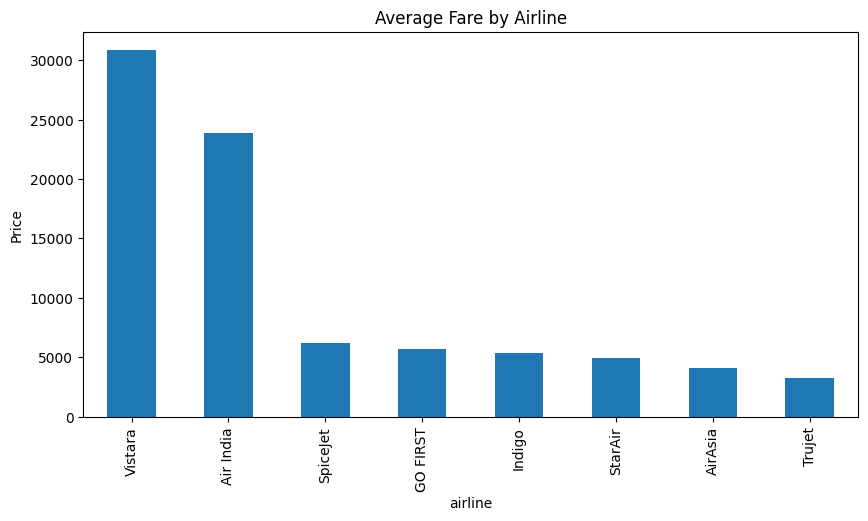

In [ ]:
import matplotlib.pyplot as plt
airline_price = (
    data.groupby('airline')['price']
    .mean()
    .sort_values(ascending=False)
)

airline_price.plot(kind='bar', figsize=(10,5))
plt.title('Average Fare by Airline')
plt.ylabel('Price')
plt.show()

Top 10 Costliest Routes

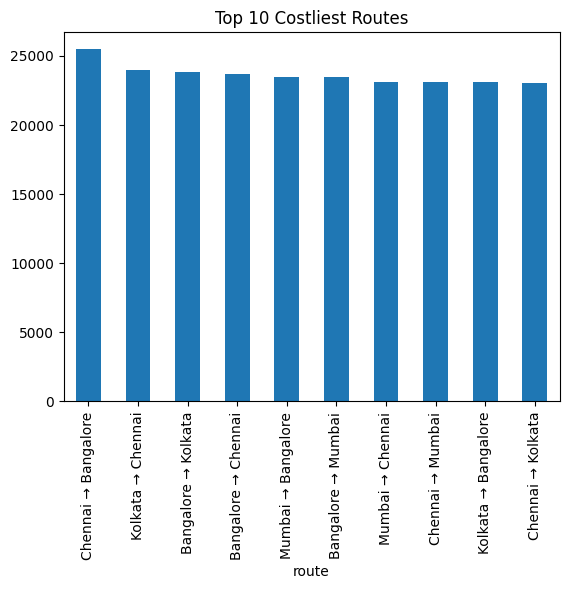

In [ ]:
top_routes = (
    data.groupby('route')['price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_routes.plot(kind='bar')
plt.title('Top 10 Costliest Routes')
plt.show()

Cheapest Routes

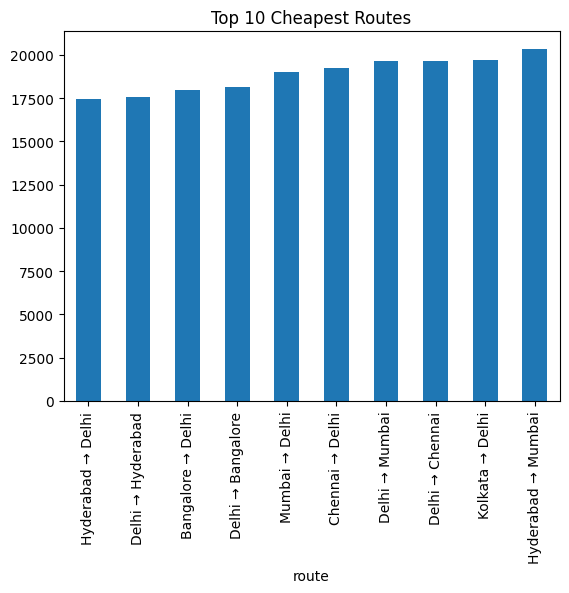

In [ ]:
cheap_routes = (
    data.groupby('route')['price']
    .mean()
    .sort_values()
    .head(10)
)

cheap_routes.plot(kind='bar')
plt.title('Top 10 Cheapest Routes')
plt.show()

Stops vs Price

In [ ]:
# Function to convert 'stops' column to numeric
def convert_stops_to_numeric(stops_str):
    if pd.isna(stops_str):
        return None
    if stops_str == 'non-stop':
        return 0
    elif 'stop' in stops_str:
        try:
            # Extract the number from strings like '1-stop', '2-stops'
            # For '1-stop', it returns '1'. For '2-stops', it returns '2'.
            return int(stops_str.split('-')[0])
        except ValueError:
            return None # Handle potential unexpected string formats
    return None

# Create the 'stops_numeric' column
data['stops_numeric'] = data['stops'].apply(convert_stops_to_numeric)

# Now perform the groupby operation
data.groupby('stops_numeric')['price'].mean()

,price
stops_numeric,
0.0,9493.462879
1.0,23217.351668


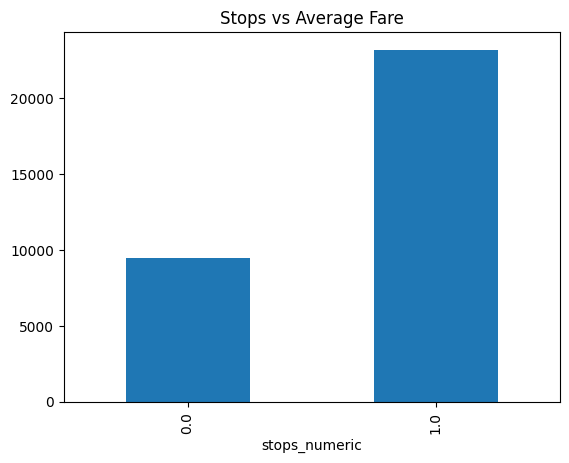

In [ ]:
data.groupby('stops_numeric')['price'].mean().plot(kind='bar')
plt.title('Stops vs Average Fare')
plt.show()

Class vs Price

In [ ]:
data.groupby('class')['price'].mean()

,price
class,
business,53328.192519
economy,6636.902898


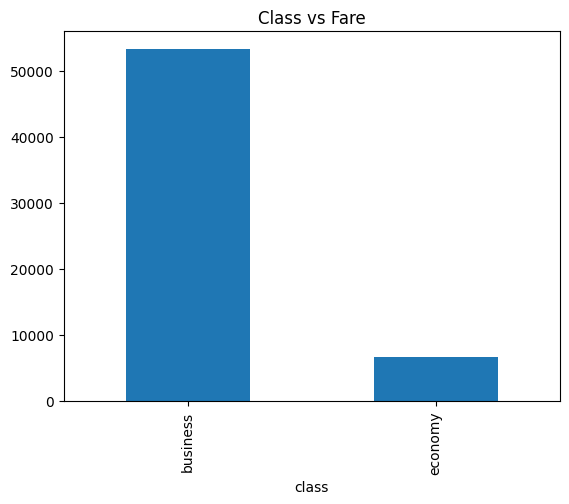

In [ ]:
data.groupby('class')['price'].mean().plot(kind='bar')
plt.title('Class vs Fare')
plt.show()

Departure Slot vs Price

In [ ]:
data.groupby('departure_slot')['price'].mean()

,price
departure_slot,
Afternoon,17743.291443
Evening,23934.751281
Morning,21594.322231
Night,19009.076847


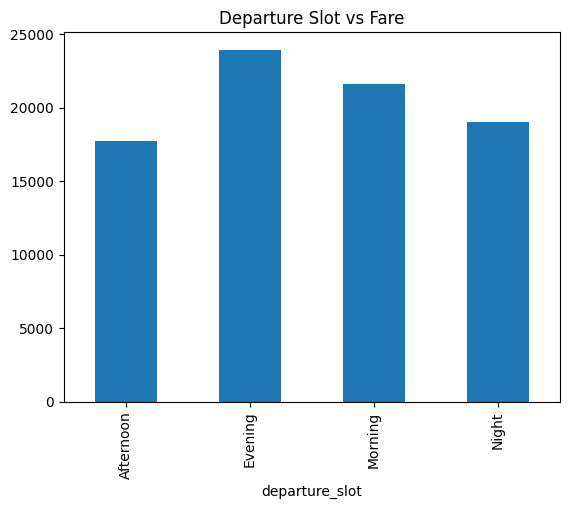

In [ ]:
data.groupby('departure_slot')['price'].mean().plot(kind='bar')
plt.title('Departure Slot vs Fare')
plt.show()

Weekend vs Weekday Pricing

In [ ]:
data.groupby('is_weekend')['price'].mean()

,price
is_weekend,
0,21289.030309
1,20898.269544


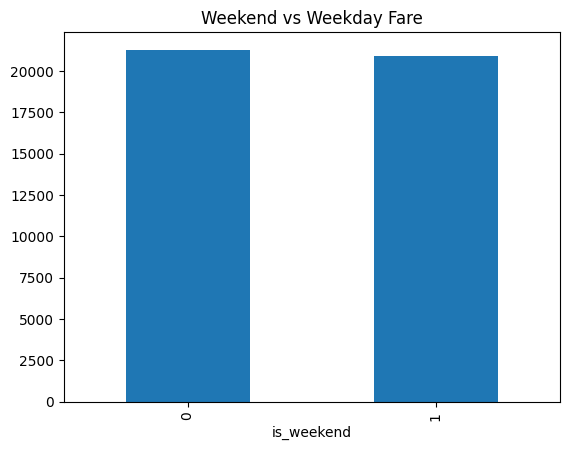

In [ ]:
data.groupby('is_weekend')['price'].mean().plot(kind='bar')
plt.title('Weekend vs Weekday Fare')
plt.show()

Price Distribution

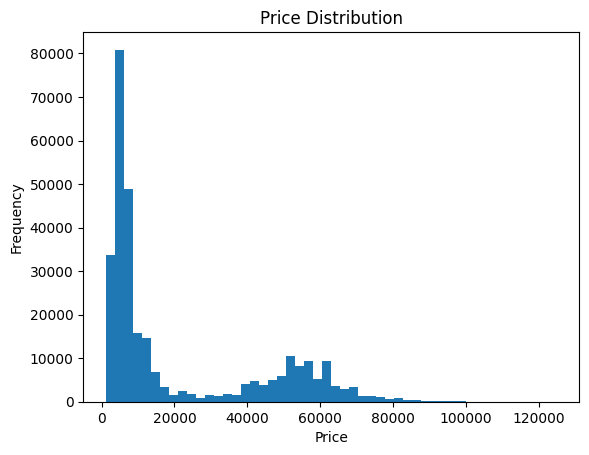

In [ ]:
import matplotlib.pyplot as plt

plt.hist(data['price'], bins=50)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

##Phase 4 KPI Generation & Business Insights

Total Flights

In [ ]:
total_flights = data.shape[0]
print(total_flights)

300259


Average Fare

In [ ]:
avg_fare = round(data['price'].mean(),2)
print(avg_fare)

21174.45


Average Duration

In [ ]:
avg_duration = round(data['duration_minutes'].mean(),2)
print(avg_duration)

733.06


Number of Airlines

In [ ]:
data['airline'].nunique()

8

Number of Routes

In [ ]:
data['route'].nunique()

30

Most Expensive Route

In [ ]:
data.groupby('route')['price'].mean().idxmax()

'Chennai → Bangalore'

Cheapest Route

In [ ]:
data.groupby('route')['price'].mean().idxmin()

'Hyderabad → Delhi'

Premium Airline

In [ ]:
data.groupby('airline')['price'].mean().idxmax()

'Vistara'

##Business Insights


Which airline has highest average fare?

In [ ]:
data.groupby('airline')['price'].mean().sort_values(ascending=False)

,price
airline,
Vistara,30831.962756
Air India,23837.936075
SpiceJet,6241.051826
GO FIRST,5708.459464
Indigo,5377.492092
StarAir,4982.016393
AirAsia,4132.026525
Trujet,3277.097561


Business vs Economy price difference

In [ ]:
data.groupby('class')['price'].mean()

,price
class,
business,53328.192519
economy,6636.902898


Weekend fares higher or lower?

In [ ]:
data.groupby('is_weekend')['price'].mean()

,price
is_weekend,
0,21289.030309
1,20898.269544


Which departure slot is most expensive?

In [ ]:
data.groupby('departure_slot')['price'].mean().sort_values(ascending=False)

,price
departure_slot,
Evening,23934.751281
Morning,21594.322231
Night,19009.076847
Afternoon,17743.291443


Non-stop vs stop flights pricing

In [ ]:
data.groupby('stops_numeric')['price'].mean()

,price
stops_numeric,
0.0,9493.462879
1.0,23217.351668


Most popular airline

In [ ]:
data['airline'].value_counts()

,count
airline,
Vistara,127859
Air India,80892
Indigo,43120
GO FIRST,23177
AirAsia,16098
SpiceJet,9011
StarAir,61
Trujet,41


Most common route

In [ ]:
data['route'].value_counts()

,count
route,
Delhi → Mumbai,15289
Mumbai → Delhi,14809
Delhi → Bangalore,14012
Bangalore → Delhi,13756
Bangalore → Mumbai,12940
Mumbai → Bangalore,12885
Mumbai → Kolkata,12602
Delhi → Kolkata,11934
Kolkata → Mumbai,11467


K-MEANS CLUSTERING


Goal: Route Segmention

In [ ]:
avg_stops = data['stops_numeric'].mean()

print(f"Average Fare: {avg_fare}")
print(f"Average Duration: {avg_duration}")
print(f"Average Stops: {avg_stops}")

Average Fare: 21174.45
Average Duration: 733.06
Average Stops: 0.874398458380812


##Phase 5 K-Means Clustering (Route Segmentation)

Route-wise aggregate

In [ ]:
route_data = (
    data.groupby('route')
    .agg({
        'price':'mean',
        'duration_minutes':'mean',
        'stops_numeric':'mean'
    })
    .reset_index()
)
route_data.head()

,route,price,duration_minutes,stops_numeric
0,Bangalore → Chennai,23648.828861,868.797972,0.918740
1,Bangalore → Delhi,17966.991131,586.785766,0.836706
2,Bangalore → Hyderabad,21448.221380,846.509508,0.895143
3,Bangalore → Kolkata,23825.431449,785.868601,0.927815
4,Bangalore → Mumbai,23452.636708,654.279892,0.870904


Feature Selection

In [ ]:
X = route_data[['price','duration_minutes','stops_numeric']]

Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Elbow Method

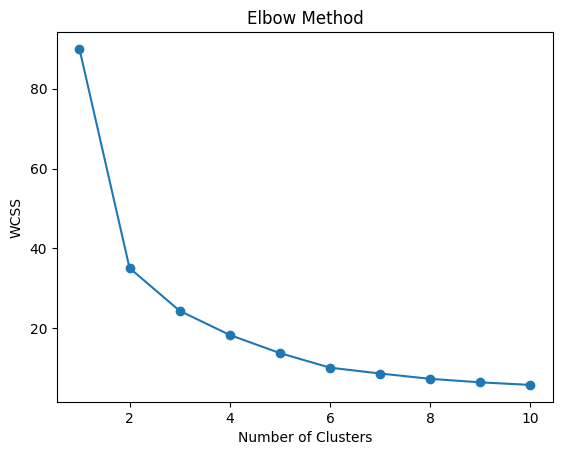

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

Choose K

In [ ]:
k = 4

Train Model

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

route_data['cluster'] = kmeans.fit_predict(X_scaled)

Cluster Counts

In [ ]:
route_data['cluster'].value_counts()

,count
cluster,
0,14
1,7
2,7
3,2


Cluster Summary

In [ ]:
cluster_summary = (
    route_data.groupby('cluster')
    [['price','duration_minutes','stops_numeric']]
    .mean()
)

print(cluster_summary)

                price  duration_minutes  stops_numeric
cluster                                               
0        22693.721627        821.334139       0.920031
1        18532.803317        674.309611       0.847731
2        22264.736881        722.452216       0.881875
3        19306.488945        605.571082       0.760096


In [ ]:
route_data['cluster'].value_counts()

,count
cluster,
0,14
1,7
2,7
3,2


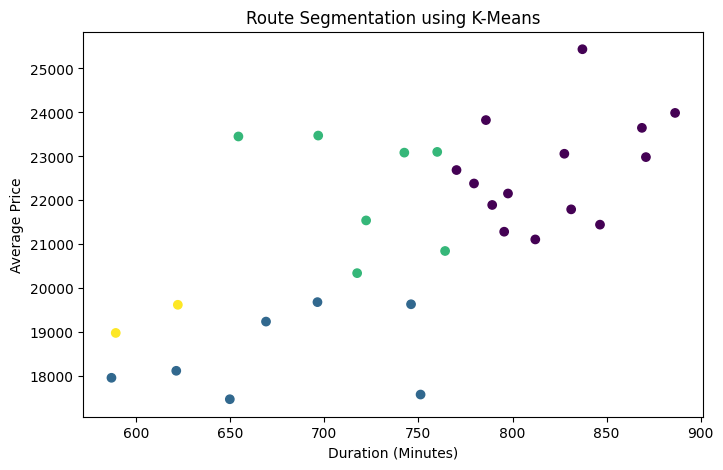

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    route_data['duration_minutes'],
    route_data['price'],
    c=route_data['cluster']
)

plt.xlabel('Duration (Minutes)')
plt.ylabel('Average Price')
plt.title('Route Segmentation using K-Means')

plt.show()

Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, route_data['cluster'])

print(score)

0.3825304846803327


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K={k}, Score={score:.4f}")

K=2, Score=0.5180
K=3, Score=0.3609
K=4, Score=0.3825
K=5, Score=0.3704
K=6, Score=0.3992


In [ ]:
cluster_names = {
    0: 'Budget Long Routes',
    1: 'Premium Fast Routes',
    2: 'Standard Routes',
    3: 'Premium Long Routes'
}

##Phase 6 - Anomaly Detection (Isolation Forest)
Business Goal

Identify:

Unusually expensive flights-
Abnormal fare patterns-
Potential pricing anomalies

Create Feature Set

In [ ]:
X_anomaly = data[
    ['price', 'duration_minutes', 'stops_numeric']
]

Scale Features

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled_anomaly = scaler.fit_transform(X_anomaly)

Train Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.02,
    random_state=42
)

data['anomaly'] = iso.fit_predict(X_scaled_anomaly)
print(data['anomaly'].value_counts())

anomaly
 1    294269
-1      5990
Name: count, dtype: int64


Count Anomalies

In [ ]:
data['anomaly'].value_counts()

,count
anomaly,
1,294269
-1,5990


Extract Anomalies

In [ ]:
anomalies = data[data['anomaly'] == -1]

anomalies.head()

,flight date,airline,flight_num,class,from,dep_time,to,arr_time,duration,price,...,day_name,weekday,is_weekend,dep_hour,arr_hour,departure_slot,duration_category,price_category,stops_numeric,anomaly
20466,2023-06-28,Vistara,UK-815,economy,Delhi,08:05:00,Kolkata,19:55:00,1 days 11:50:00,17637,...,Wednesday,2,0,8,19,Morning,Long,Premium,NaN,-1
20469,2023-06-28,Vistara,UK-801,economy,Delhi,09:05:00,Kolkata,19:55:00,1 days 10:50:00,19116,...,Wednesday,2,0,9,19,Morning,Long,Premium,NaN,-1
35404,2023-06-26,Vistara,UK-801,economy,Delhi,09:05:00,Chennai,19:55:00,1 days 10:50:00,18945,...,Monday,0,0,9,19,Morning,Long,Premium,NaN,-1
35405,2023-06-26,Vistara,UK-815,economy,Delhi,08:05:00,Chennai,19:55:00,1 days 11:50:00,18945,...,Monday,0,0,8,19,Morning,Long,Premium,NaN,-1
35409,2023-06-26,Vistara,UK-747,economy,Delhi,06:30:00,Chennai,19:55:00,1 days 13:25:00,20272,...,Monday,0,0,6,19,Morning,Long,Premium,NaN,-1


Percentage of Anomalies

In [ ]:
anomaly_pct = (
    len(anomalies) / len(data)
) * 100

print(f"{anomaly_pct:.2f}%")

1.99%


Most Expensive Anomalies

In [ ]:
anomalies[
    ['airline','route','price']
].sort_values(
    'price',
    ascending=False
).head(10)

,airline,route,price
261485,Vistara,Kolkata → Delhi,124917
216204,Vistara,Delhi → Kolkata,119067
215967,Vistara,Delhi → Kolkata,118310
277453,Vistara,Hyderabad → Mumbai,116939
271107,Vistara,Kolkata → Hyderabad,116426
290676,Vistara,Chennai → Mumbai,116425
230200,Vistara,Mumbai → Bangalore,116241
219291,Vistara,Delhi → Hyderabad,116225
215966,Vistara,Delhi → Kolkata,116151
241707,Vistara,Mumbai → Chennai,113643


Visualization

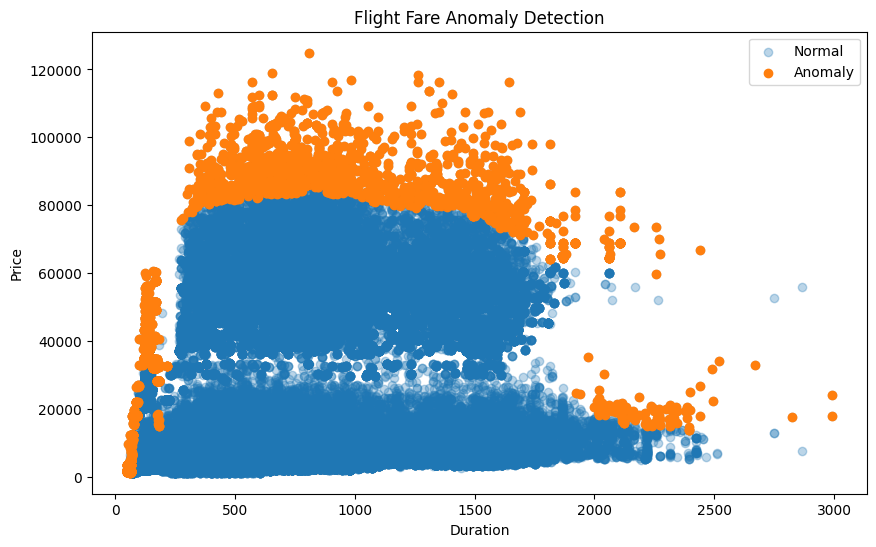

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    data['duration_minutes'],
    data['price'],
    alpha=0.3,
    label='Normal'
)

plt.scatter(
    anomalies['duration_minutes'],
    anomalies['price'],
    label='Anomaly'
)

plt.xlabel('Duration')
plt.ylabel('Price')
plt.title('Flight Fare Anomaly Detection')

plt.legend()
plt.show()